<a href="https://colab.research.google.com/github/nany11antunez/urban-mobility-economic-analysis/blob/main/urban_mobility_economic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# Mostrar las primeras 5 filas del DataFrame de Tráfico
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [ ]:
# Examinar la estructura de traffic
print("info: dataset traffic")
traffic.info()
print("first 3 rows of traffic")
display(traffic.head(3))

info: dataset traffic
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 n

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo texto (object) pero deberían convertirse a datetime64 para poder operar con fechas, extraer el año de forma analítica y filtrar periodos correspondientes.
- En el dataset traffic, el reporte indica 1,004,464 entradas y todas las columnas registran exactamente non-null (no hay nulos ni valores ausentes)

In [ ]:
# Examinar la estructura de eco
print("info: dataset eco")
eco.info()
print("First 3 rows of eco")
display(eco.head(3))

info: dataset eco
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
First 3 rows of eco


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"




En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`,`PM2.5 (μg/m³)` y `Population (M)` son de tipo object (texto) debe limpiarse y convertirse a float64. ...
- En el dataset eco, el reporte indica 30 entradas y todas sus columnas muestran exactamente non-null (no hay nulos ni valores ausentes).


In [ ]:

# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms':
'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins',
    'MinsDelay': 'mins_delay'

})
# verificar cambios
traffic.columns



Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco

eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'gdp_capita',
    'Unemployment %': 'unemployment_rate',
    'PM2.5 (μg/m³)': 'pm25',
    'Population (M)': 'population_m'
})
# verificar cambios
eco.columns


Index(['year', 'city', 'country', 'gdp_capita', 'unemployment_rate', 'pm25',
       'population_m'],
      dtype='object')

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [ ]:

# Limpia separadores y convertir columnas numéricas en eco
eco['gdp_capita'] = eco['gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_rate'] = eco['unemployment_rate'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False).astype(float)
eco['pm25'] = eco['pm25'].astype(str).str.replace(',', '.', regex=False).astype(float)
# Calcula la población total en unidades absolutas
eco['population'] = eco['population_m'] * 1000000
eco.info()
eco.head(3)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               30 non-null     int64  
 1   city               30 non-null     object 
 2   country            30 non-null     object 
 3   gdp_capita         30 non-null     float64
 4   unemployment_rate  30 non-null     float64
 5   pm25               30 non-null     float64
 6   population_m       30 non-null     float64
 7   population         30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,gdp_capita,unemployment_rate,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,gdp_capita,unemployment_rate,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'])[[
    'jams_delay',
    'traffic_index_live',
    'jams_length_in_kms',
    'jams_count',
    'mins_delay',
    'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins'
]].agg('mean').reset_index()
# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:

traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es mexico-city, con un jams_delay de 2833.05. A pesar de que Manila tiene el índice de congestión en vivo más alto, mexico-city destaca porque su red urbana es masiva, acumulando un promedio de 389 km de embotellamientos continuos frente a los 246 km de Manila. Esta enorme extensión, sumada a una mayor cantidad de focos de congestión (jams_count) de 594.96, es lo que dispara el retraso total acumulado en toda la ciudad.

In [ ]:
#Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','gdp_capita','unemployment_rate','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,gdp_capita,unemployment_rate,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0


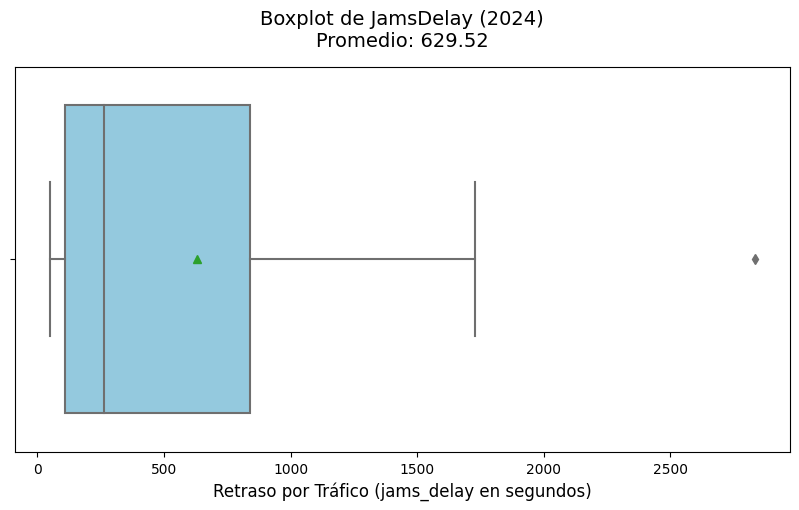

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
plt.figure(figsize=(10, 5))
sns.boxplot(x=merged['jams_delay'], color='skyblue', showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}', fontsize=14, pad=15)
plt.xlabel('Retraso por Tráfico (jams_delay en segundos)', fontsize=12)

plt.show()

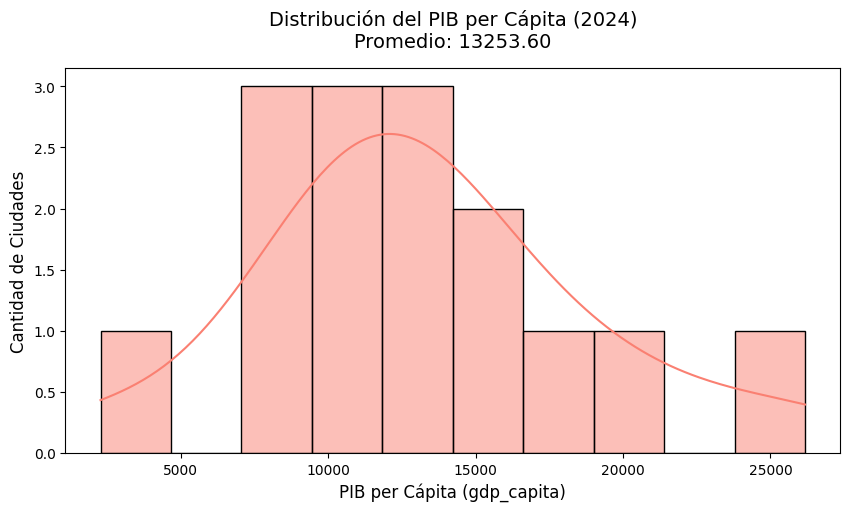

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.figure(figsize=(10, 5))
sns.histplot(data=merged, x='gdp_capita', bins=10, kde=True, color='salmon')
mean_gdp = merged['gdp_capita'].mean()
plt.title(f'Distribución del PIB per Cápita (2024)\nPromedio: {mean_gdp:.2f}', fontsize=14, pad=15)
plt.xlabel('PIB per Cápita (gdp_capita)', fontsize=12)
plt.ylabel('Cantidad de Ciudades', fontsize=12)


plt.show()

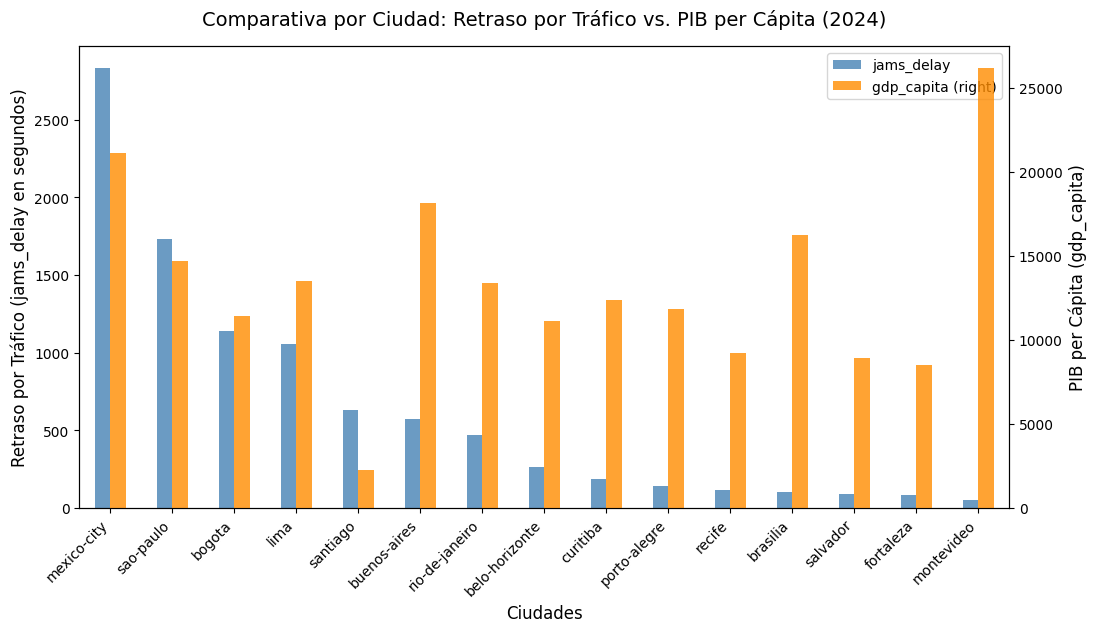

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged_sorted = merged.sort_values('jams_delay', ascending=False)

ax = merged_sorted.plot(
    x='city',
    y=['jams_delay', 'gdp_capita'],
    kind='bar',
    secondary_y=['gdp_capita'],
    figsize=(12, 6),
    color=['steelblue', 'darkorange'],
    alpha=0.8
)
plt.title('Comparativa por Ciudad: Retraso por Tráfico vs. PIB per Cápita (2024)', fontsize=14, pad=15)
ax.set_xlabel('Ciudades', fontsize=12)
ax.set_ylabel('Retraso por Tráfico (jams_delay en segundos)', fontsize=12)
ax.right_ax.set_ylabel('PIB per Cápita (gdp_capita)', fontsize=12)

ax.set_xticklabels(merged_sorted['city'], rotation=45, ha='right')

plt.xticks(rotation=90)
plt.show()

Al contrastar las tres visualizaciones no existe una relación lineal o directa entre el PIB per cápita y el retraso por tráfico, el comportamiento de los datos parece ser mucho más complejo. El dinero que genera una ciudad no predice de forma automática o proporcional cuántos atascos va a tener en su día a día.

Esto sugiere que para la mayoría de las ciudades, la congestión depende de otros factores ajenos a la riqueza, como el tamaño de la población o podría estar influenciado por factores como eficiencia del diseño urbanístico.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---
# 🧾 Resumen ejecutivo (plantilla)

**Contexto & objetivo:**  
- ¿Qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)? A nivel global y regional.

Los datos del dataset (ciudades LATAM, 2024) muestran que **no existe una relación lineal directa o proporcional** entre la movilidad urbana y la productividad económica. Un mayor PIB per cápita no disminuye el tráfico de forma progresiva. **El tráfico diario está gobernado por la escala de la población y no de la economía**. El dinero solo hace la diferencia en los extremos: un PIB muy bajo podría genera alta congestión por falta de inversión, mientras que un PIB muy alto permite financiar la infraestructura necesaria para reducir el tráfico casi a cero.

* **Ausencia de relación lineal (Escala poblacional):** Ciudades con economías más fuertes como **México (CDMX)** o **Argentina (Buenos Aires)** **Brasil (Sao Paulo)** registran niveles de congestión altos, demuestran que un PIB alto no disminuye el tráfico; sus masivas poblaciones saturan las calles, demostrando que la población manda sobre el tráfico.
* **Extremo de vulnerabilidad (PIB bajo):** **Colombia (Bogotá)** y **Perú (Lima)** comprueban que un PIB limitado perpetúa el colapso vial por la imposibilidad de financiar infraestructura masiva de forma autónoma.
* **Extremo de mitigación (PIB alto):** **Uruguay (Montevideo)** confirma que la suficiencia económica extrema sí logra arrastrar los índices de tráfico a niveles mínimos.


**Variables de Movilidad (Diagnóstico de la congestión):**
* **`jams_delay`:** Mide el tiempo total en segundos que pierden los conductores debido a los embotellamientos. Es el indicador directo para medir la urgencia de una intervención vial.
* **`travel_time_live_per_10kms_mins`:** Indica los minutos necesarios para recorrer 10 kilómetros en tiempo real. Esta variable es crucial para el banco porque mide la ineficiencia de la red de transporte y las pérdidas de productividad por cada viaje.

**Variables Socioeconómicas (Priorización de la inversión):**
* **`gdp_capita` y `population`:** Son las métricas principales para dirigir los fondos, pero siempre analizadas en combinación con los datos de tráfico. La prioridad crítica del banco no se define solo por un PIB bajo, sino por la coexistencia de dos factores una alta congestión operativa (`jams_delay` elevado) y una baja capacidad económica (`gdp_capita` bajo).
* **`pm25` (Calidad del aire):** Monitorea las partículas contaminantes finas. Es clave para un banco de desarrollo ya que permite justificar proyectos de transporte limpio (como metros o buses eléctricos) que no solo alivien el tráfico, sino que reduzcan el impacto ambiental y mejoren la salud pública.
    
**Cobertura de datos:**  

Para garantizar la transparencia y el alcance técnico de este reporte, la muestra final integrada se delimitó bajo los siguientes parámetros de control:
* **Período cronológico:** El análisis se concentra estrictamente en los datos consolidados del año **2024**.
* **Alcance geográfico:** El dataset final integrado abarca un total de **15 ciudades principales**, las cuales representan a **7 países** de la región latinoamericana.
* **Países incluidos:** Argentina (`ARG`), Brasil (`BRA`), Chile (`CHL`), Colombia (`COL`), México (`MEX`), Perú (`PER`) y Uruguay (`URY`).
* **Criterio de representatividad:** Cada registro en el dataset representa una entidad urbana única donde coincidieron de manera exitosa las métricas de movilidad en tiempo real de *TomTom Traffic Index* y los indicadores socioeconómicos de *OECD Cities*.

**Metodología (alto nivel):**  

El procesamiento de la información se estructuró en tres etapas principales utilizando Python y la librería Pandas para asegurar la trazabilidad y calidad del análisis:

1. **Limpieza, conversión de tipos y estandarización:** Se realizó una auditoría de calidad para corregir las discrepancias estructurales entre ambas fuentes:
   * **Parseo de fechas:** El dataset de tráfico no tenía un campo de año nativo, por lo que se transformaron las cadenas de texto (`strings`) a objetos de tipo fecha (`datetime`) para extraer el año de forma precisa y filtrar el período 2024.
   * **Casteo de datos numéricos:** Se limpiaron y normalizaron las columnas económicas (eliminando caracteres especiales como puntos, comas y símbolos de porcentaje) para convertirlas a tipos de datos numéricos (`float`/`int`), permitiendo así el análisis estadístico.
   * **Estandarización de variables:** se renombraron las columnas de ambas fuentes para garantizar una estructura homogénea.

2. **Fusión e integración (`INNER JOIN`):** Para consolidar la información, los conjuntos de datos se estructuraron bajo una clave común de agregación basada en la combinación **ciudad–año**. Posteriormente, se aplicó una unión de tipo **`INNER JOIN`** para enlazar las métricas de tráfico con los indicadores económicos. Este enfoque garantizó el rigor del análisis, incluyendo en la muestra final únicamente aquellas ciudades que contaban con registros completos, simultáneos y vigentes en ambas fuentes de datos (TomTom Traffic Index y OECD Cities)  .

3. **Validación visual y control de calidad:** Una vez unificados los datos, se emplearon tres herramientas de análisis exploratorio (EDA) para validar el comportamiento de las variables y asegurar la solidez del modelo:
   * **Histogramas:** Utilizados para evaluar la distribución y concentración de la riqueza urbana (`gdp_capita`).
   * **Boxplots (Diagramas de caja):** Implementados para identificar visualmente la dispersión y la presencia de valores atípicos (*outliers*) en los retrasos por tráfico (`jams_delay`).
   * **Gráficos de barras comparativos:** Empleados para contrastar de forma directa el cruce de variables y detectar las tendencias generales entre la movilidad y la productividad.


**Hallazgos iniciales:**  

  **Patrones principales (Tráfico vs. PIB per cápita):** Se observa una relación no lineal entre ambas variables. En los niveles de ingresos bajos y medios, la población es el principal motor del tráfico, generando un estancamiento generalizado donde las ciudades de ingresos medios presentan niveles de congestión muy similares debido a que el crecimiento demográfico supera la capacidad vial, independientemente de pequeñas variaciones en su PIB. Sin embargo, en los extremos la economía se vuelve determinante: los niveles más críticos de retraso (`jams_delay`) se concentran en ciudades con menor PIB per cápita, mientras que un PIB per cápita significativamente alto actúa como un mitigador, permitiendo infraestructura que reduce el impacto del tráfico a niveles mínimos.
 **Anomalías y Outliers:** Se identifican dos tipos de valores atípicos que requieren un análisis más profundo:
  * **Outliers de alta congestión:** Ciudades como **Bogotá**, que a pesar de no alcanzar la escala demográfica extrema de megaciudades como São Paulo o CDMX registra un `jams_delay` desproporcionadamente elevado y casi idéntico al de ellas, lo que apunta a fallas estructurales graves en su red vial.
  * **Outliers de eficiencia:** Ciudades como **Montevideo** con un PIB per cápita alto que logran mantener niveles de congestión extremadamente bajos, rompiendo la tendencia general y sirviendo como casos de estudio para mejores prácticas.

**Recomendaciones**  

Basado en el cruce de variables de movilidad, capacidad económica local y el análisis de correlación del subgrupo crítico, se establecen las siguientes acciones estratégicas para el banco de desarrollo:

1. **Identificación de la Ciudad Prioridad Crítica (Bogotá):**
   * **Bogotá** es la candidata prioritaria indiscutible para la inversión en infraestructura de transporte masivo. Los datos demuestran que es la ciudad que mejor ilustra la crisis del extremo de vulnerabilidad: **registra el retraso por tráfico más agudo del subgrupo (≈1141 segundos) en combinación con el PIB per cápita más bajo (≈11,442 dólares).** Al carecer de músculo financiero propio para desarrollar obras de gran envergadura (como la expansión del metro o sistemas ferroviarios pesados), la intervención del banco generará el mayor impacto social y de productividad en esta urbe.
     
   * *Nota sobre Lima y Buenos Aires:* **Lima** se consolida como la segunda prioridad del análisis; presenta un escenario de vulnerabilidad severa muy cercano al de la capital colombiana al registrar un retraso crítico de **≈1052 segundos** sostenido por un PIB per cápita limitado de **≈13,472 dólares**. Por su parte, Buenos Aires queda descartada como prioridad urgente debido a que su **PIB per cápita es significativamente superior (≈18,117 dólares) y su índice de retraso es notablemente menor (571 segundos)**; este mayor músculo financiero relativo le otorga la capacidad presupuestaria y de endeudamiento necesaria para gestionar sus desafíos viales de forma autónoma.
  
2. **Propuestas de Inversión Sostenible:**
   * Dirigir los fondos de financiamiento en Bogotá hacia proyectos de **transporte masivo eléctrico y segregado** (priorización de líneas de metro y troncales exclusivas). Esto permitirá atacar simultáneamente el cuello de botella económico del tráfico y reducir los niveles de contaminación del aire (`pm25`), ya que los datos del dataset confirman que Bogotá registra un índice de contaminación de **17.60 µg/m³** justificando técnicamente la inversión bajo criterios internacionales de sostenibilidad.
  
     


3. **Validación de Fuentes y Análisis Adicionales:**
  
* **Auditoría de la conversión del PIB (Acción Concreta):** El banco debe **solicitar una validación independiente que cruce de forma directa los datos de la OCDE con las bases de paridad de poder adquisitivo (PPA) del Banco Mundial para todas las ciudades de la muestra**. Esta auditoría técnica se debe realizar antes de la aprobación final de los fondos, con el objetivo de asegurar que las fluctuaciones de la tasa de cambio nominal o los sesgos de normalización no distorsionen la capacidad económica real medida, ratificando así la idoneidad del eje Bogotá-Lima como el bloque prioritario de financiamiento.
* **Análisis Longitudinal (Series de Tiempo):** Requerir una ampliación del estudio para evaluar el comportamiento del `jams_delay` a lo largo de los últimos 3 a 5 años. Esta evaluación es crítica para definir la naturaleza de la intervención del banco:

     * **Si se confirma un problema estructural:** Se justificará la aprobación de fondos para proyectos de infraestructura pesada de largo plazo (como nuevas líneas de metro o trenes urbanos).
     * **Si se detecta un factor estacional o coyuntural:** (por ejemplo, tráfico inflado de forma temporal por frentes de obra activos o desviaciones durante 2024), el banco deberá reorientar la inversión hacia soluciones de gestión de tráfico inteligente, optimización de redes existentes o aplazar el desembolso hasta la normalización de la línea de base vial o en su defecto, redireccionar los fondos hacia la siguiente ciudad prioritaria en el ranking, como Lima.
  